# Deconvolution

### Imports


In [1]:
import cupy
import matplotlib.pyplot as plt
import numpy as np
import s3fs
import zarr

from cupyx.scipy.ndimage import (
    gaussian_laplace as cupy_gaussian_laplace,
    maximum_filter as cupy_maximum_filter,
)
from deep_neurographs.utils import img_util, swc_util
from scipy.ndimage import gaussian_laplace, gaussian_filter, maximum_filter, center_of_mass
from skimage.measure import label
from skimage.feature import peak_local_max
from time import time

%matplotlib inline

IMG_PREFIX = {
    "685221": "exaSPIM_685221_2024-04-12_11-46-38_fusion_2024-07-22_21-00-15",
    "703070": "exaSPIM_703070_2024-07-09_12-52-33_flatfield-correction_2024-07-18_12-43-27_fusion_2024-08-02_17-11-59",
    "706301": "exaSPIM_706301_2024-04-23_11-24-24_fusion_2024-05-21_00-00-03",
    "708369": "exaSPIM_708369_2024-04-08_15-20-36_fusion_2024-05-20_23-30-43",
    "709393": "exaSPIM_709393_2024-04-17_09-37-51_fusion_2024-07-27_00-20-20",
    "715345": "exaSPIM_715345_2024-06-07_10-03-37_fusion_2024-07-02_10-30-40"
}

In [2]:
# Subroutines
def rescale(arr, clip_bool=True):
    if clip_bool:
        arr = np.clip(arr, 0, np.percentile(arr, 99.99))
    arr -= np.min(arr)
    arr = (2**16 - 1) * (arr / np.max(arr))
    return (arr).astype(np.uint16)


def get_mip(arr, axis=0, clip_bool=False):
    mip = np.max(arr, axis=axis)
    mip = rescale(mip, clip_bool=clip_bool)
    return mip


def read_from_s3(img, voxel, shape, from_center=True):
    start, end = img_util.get_start_end(voxel, shape, from_center=from_center)
    return img[0, 0, start[2]:end[2], start[1]:end[1], start[0]:end[0]]


def plot_mips(volume, prefix="", clip_bool=True):
    fig, axs = plt.subplots(1, 3, figsize=(10, 4))
    axs_names = ["XY", "XZ", "YZ"]
    for i in range(3):
        axs[i].imshow(get_mip(volume, axis=i, clip_bool=clip_bool))
        axs[i].set_title(prefix + axs_names[i], fontsize=16)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
    plt.tight_layout()
    plt.show()


def find_candidates(img_patch):
    # Smooth image
    img_patch = gaussian_filter(img_patch, [2, 2, 1.5])

    # Compute LoG
    img_patch = gaussian_laplace(img_patch, 8)

    # Find blob centroids
    labels, n_labels = label(img_patch > 100, return_num=True)
    return center_of_mass(img_patch, labels=labels, index=np.arange(n_labels))


### Opem img

In [3]:
# Parameters
s3_bucket = "aind-open-data"
dataset = "706301"
downsample_factor = 4

# Initializations
fs = s3fs.S3FileSystem()
s3_url = f"s3://{s3_bucket}/{IMG_PREFIX[dataset]}/fused.zarr/{downsample_factor}/"

# Open img
store = s3fs.S3Map(root=s3_url, s3=fs)
img = zarr.open(store, mode='r')
print("img.shape:", img.shape)

img.shape: (1, 1, 1812, 1821, 3895)


### Read img

In [4]:
traceable_somas = [
    [18403.324, 11245.411, 2675.9985],
    [23425.596, 8926.942, 2185.401],
    [18400.334,11231.872,2683.3584],
    [21624.133,7740.173,12768.359],
    [22883.316,4323.8574,16284.648],
    [43937.27,5479.154,12344.152],
]

bright_nonsomas = [
    [20026.29,6470.747,14384.427],
    [18330.354,3822.579,14477.964],
    [22800.148,2251.1611,16850.379],
    [37846.895,6913.5713,20431.992],
    [43469.51,4820.5303,16769.32],
    [44225.082,4402.9487,15589.198],
]

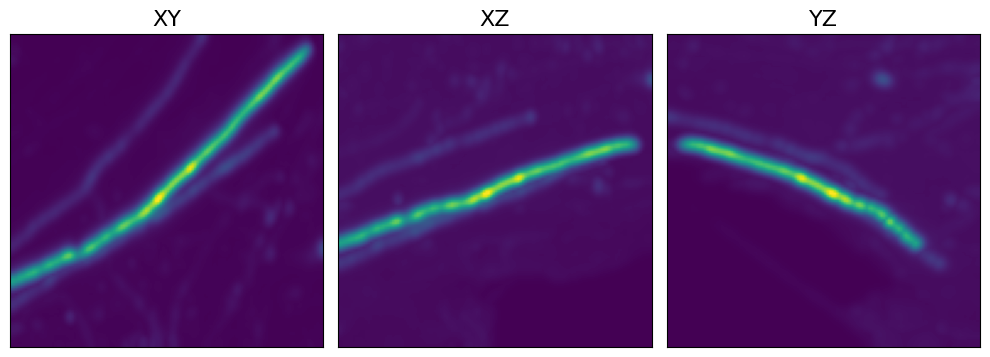

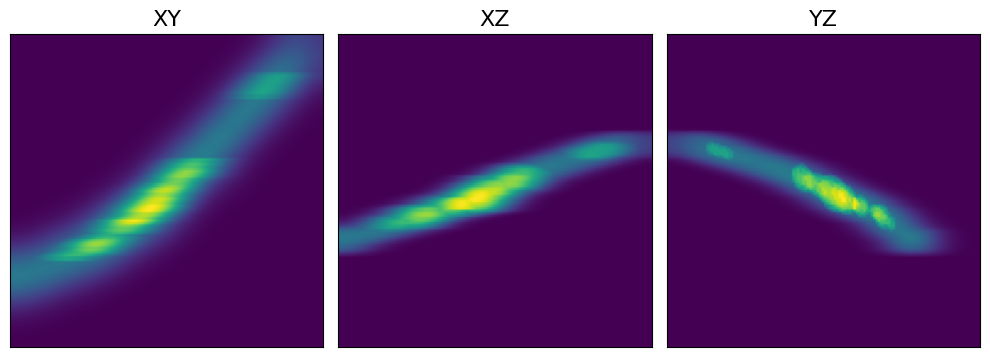

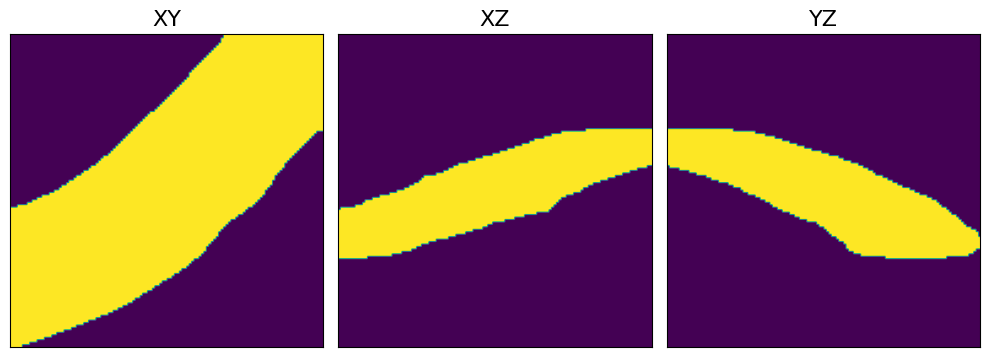

# Objects Detected: 1
[(42.726854522173916, 74.10032874736017, 62.27372095478763)]
[1943480  153672]


In [5]:
# Region of interest
idx = 4
shape = [128, 128, 128]
from_center = True

# Read img
voxel = img_util.to_voxels(bright_nonsomas[idx], downsample_factor=downsample_factor)
img_chunk = read_from_s3(img, voxel, shape, from_center=from_center)

# Smooth with Gaussian Filter
img_chunk = gaussian_filter(img_chunk, [2, 2, 1.5])
plot_mips(img_chunk)

# Compute LoG
t0 = time()
log_img = gaussian_laplace(img_chunk, 8)
plot_mips(log_img)

# Find blob centroids
labels, n_labels = label(log_img > 100, return_num=True)
plot_mips(labels)

component_sizes = np.bincount(labels.ravel())
print("# Objects Detected:", n_labels)
print(center_of_mass(img_chunk, labels=labels, index=np.arange(n_labels)))
print(component_sizes)


## Large-Scale Experiment

In [6]:
def sliding_window_coords_3d(image, window_size=(128, 128, 128), overlap=(32, 32, 32)):
    # Calculate the stride based on the overlap and window size
    stride = tuple(w - o for w, o in zip(window_size, overlap))
    
    # Get dimensions of the image and window
    _, _, z_dim, y_dim, x_dim = image.shape
    z_win, y_win, x_win = window_size
    z_stride, y_stride, x_stride = stride

    # Loop over the image with the sliding window
    coordinates = []
    for z in range(0, z_dim - z_win + 1, z_stride):
        for y in range(0, y_dim - y_win + 1, y_stride):
            for x in range(0, x_dim - x_win + 1, x_stride):
                coordinates.append((z, y, x))
    return coordinates



# Get the sliding windows and their coordinates
coordinates = sliding_window_coords_3d(img)


In [8]:
t0 = time()
find_candidates(img_chunk)
print("Runtime:", time() - t0)

Runtime: 0.8581833839416504


In [ ]:
swc_utils.save_point